In [9]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


stim_sequence = [
    {"n_beats": 200,
     "cycle_length": 1000.,
     "stim_duration": 0.5,
     "stim_amplitude": 100.,
     "dt": 0.01},
    # {"n_beats": 3,
    #  "cycle_length": 500.,
    #  "stim_duration": 0.5,
    #  "stim_amplitude": 100.,
    #  "dt": 0.01},
    #  {"n_beats": 3,
    #  "cycle_length": 300.,
    #  "stim_duration": 0.5,
    #  "stim_amplitude": 100.,
    #  "dt": 0.01},
]

dt = 0.01
# create a tissue of size 400x400 with cardiomycytes:
cardiac_model = fw.Courtemanche()

before_state = {var: getattr(cardiac_model, "init_" + var) for var in cardiac_model.state_vars}

cardiac_model.prepacing(stim_sequence)

print(cardiac_model.init_u)
print(getattr(cardiac_model, "init_u"))

after_state = {var: getattr(cardiac_model, "init_" + var) for var in cardiac_model.state_vars}

# cardiac_model.run(dt)


# for var in cardiac_model.state_vars:
#     print(var, getattr(cardiac_model, "init_" + var))
# cardiac_model.prepacing(stim_sequence)
# %timeit cardiac_model.run(dt)

# time = np.arange(0, len(cardiac_model.u_pacing)*dt, dt)

# plt.plot(time, cardiac_model.u_pacing)
# plt.xlabel("Time (ms)")
# plt.ylabel("Membrane potential (mV)")
# plt.title("Pacing Protocol")
# plt.show()

-81.21844916895145
-81.21844916895145


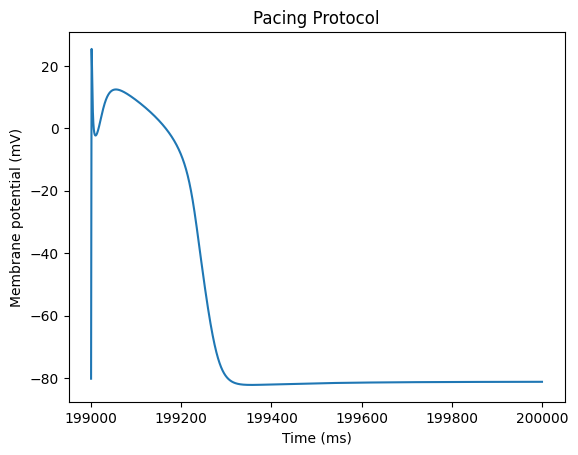

In [10]:
time = np.arange(0, len(cardiac_model.u_pacing)*dt, dt)

plt.plot(time[-100000:], cardiac_model.u_pacing[-100000:])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Pacing Protocol")
plt.show()

In [7]:
for k, v in before_state.items():
    print(f"Before vs After - {k}: {v:.4f} vs {after_state[k]:.4f}")

Before vs After - u: -84.5000 vs -81.2184
Before vs After - nai: 11.2000 vs 11.2000
Before vs After - ki: 139.0000 vs 138.9999
Before vs After - cai: 0.0001 vs 0.0001
Before vs After - caup: 1.6000 vs 1.5016
Before vs After - carel: 1.1000 vs 1.5016
Before vs After - m: 0.0029 vs 0.0029
Before vs After - h: 0.9650 vs 0.9652
Before vs After - j_: 0.9780 vs 0.9777
Before vs After - d: 0.0001 vs 0.0001
Before vs After - f: 0.9998 vs 0.8896
Before vs After - oa: 0.0006 vs 0.0304
Before vs After - oi: 0.9992 vs 0.9992
Before vs After - ua: 0.0035 vs 0.0049
Before vs After - ui: 0.9987 vs 0.9764
Before vs After - xr: 0.0000 vs 0.0059
Before vs After - xs: 0.0187 vs 0.0194
Before vs After - fca: 0.7750 vs 0.7737
Before vs After - irel: 0.0000 vs 0.0000
Before vs After - vrel: 1.0000 vs 1.0000
Before vs After - urel: 0.0000 vs 0.0000
Before vs After - wrel: 0.9000 vs 0.9992


In [1]:
import numpy as np
from numba import njit
from importlib.metadata import entry_points

REQS = ("get_variables", "get_parameters")


def discover() -> dict:
    eps = entry_points(group="finitewave.models")
    return {ep.name: ep for ep in eps}


def load_ops(model_id: str):
    eps = discover()
    if model_id not in eps:
        raise KeyError(f"Model '{model_id}' not found via entry point 'finitewave.models'.")
    mod = eps[model_id].load()   # ops package
    ops = getattr(mod, "ops", mod)
    for name in REQS:
        if not hasattr(ops, name):
            raise ValueError(f"Model '{model_id}' missing '{name}' in ops.")
    return ops

def wrap_calc(ops):
    jitted = {}
    fns = getattr(ops, "__all__", [])
    fns = [fn for fn in fns if fn.startswith("calc_")]
    for name in fns:
        fn = getattr(ops, name)
        if callable(fn):
            ops.__dict__[name] = njit(cache=True)(fn)
            jitted[name] = njit(cache=True)(fn)
    return jitted


ops = load_ops("courtemanche")
jit_ops = wrap_calc(ops)

calc_rhs = jit_ops["calc_rhs"]
calc_where = jit_ops["calc_where"]
calc_gating_variable = jit_ops["calc_gating_variable"]
calc_gating_variable_rush_larsen = jit_ops["calc_gating_variable_rush_larsen"]
calc_cmdn = jit_ops["calc_cmdn"]
calc_trpn = jit_ops["calc_trpn"]
calc_csqn = jit_ops["calc_csqn"]
calc_dnai = jit_ops["calc_dnai"]
calc_dki = jit_ops["calc_dki"]
calc_dcai = jit_ops["calc_dcai"]
calc_dcaup = jit_ops["calc_dcaup"]
calc_dcarel = jit_ops["calc_dcarel"]
calc_equilibrum_potentials = jit_ops["calc_equilibrum_potentials"]
calc_ina = jit_ops["calc_ina"]
calc_gating_m = jit_ops["calc_gating_m"]
calc_gating_h = jit_ops["calc_gating_h"]
calc_gating_j = jit_ops["calc_gating_j"]
calc_ik1 = jit_ops["calc_ik1"]
calc_ito = jit_ops["calc_ito"]
calc_ikur = jit_ops["calc_ikur"]
calc_ikr = jit_ops["calc_ikr"]
calc_iks = jit_ops["calc_iks"]
calc_ical = jit_ops["calc_ical"]
calc_inak = jit_ops["calc_inak"]
calc_inaca = jit_ops["calc_inaca"]
calc_ibca = jit_ops["calc_ibca"]
calc_ibna = jit_ops["calc_ibna"]
calc_ipca = jit_ops["calc_ipca"]
calc_irel = jit_ops["calc_irel"]
calc_itr = jit_ops["calc_itr"]
calc_iup = jit_ops["calc_iup"]
calc_iupleak = jit_ops["calc_iupleak"]

In [2]:
parameters = ops.get_parameters()
gna = parameters["gna"]
gnab = parameters["gnab"]
gk1 = parameters["gk1"]
gkr = parameters["gkr"]
gks = parameters["gks"]
gto = parameters["gto"]
gcal = parameters["gcal"]
gcab = parameters["gcab"]
gkur_coeff = parameters["gkur_coeff"]
F = parameters["F"]
T = parameters["T"]
R = parameters["R"]
Vc = parameters["Vc"]
Vj = parameters["Vj"]
Vup = parameters["Vup"]
Vrel = parameters["Vrel"]
ibk = parameters["ibk"]
cao = parameters["cao"]
nao = parameters["nao"]
ko = parameters["ko"]
caupmax = parameters["caupmax"]
kup = parameters["kup"]
kmnai = parameters["kmnai"]
kmko = parameters["kmko"]
kmnancx = parameters["kmnancx"]
kmcancx = parameters["kmcancx"]
ksatncx = parameters["ksatncx"]
kmcmdn = parameters["kmcmdn"]
kmtrpn = parameters["kmtrpn"]
kmcsqn = parameters["kmcsqn"]
trpnmax = parameters["trpnmax"]
cmdnmax = parameters["cmdnmax"]
csqnmax = parameters["csqnmax"]
inacamax = parameters["inacamax"]
inakmax = parameters["inakmax"]
ipcamax = parameters["ipcamax"]
krel = parameters["krel"]
iupmax = parameters["iupmax"]
kq10 = parameters["kq10"]

variables = ops.get_variables()
u = variables["u"]
nai = variables["nai"]
ki = variables["ki"]
cai = variables["cai"]
caup = variables["caup"]
carel = variables["carel"]
m = variables["m"]
h = variables["h"]
j_ = variables["j"]
d = variables["d"]
f = variables["f"]
oa = variables["oa"]
oi = variables["oi"]
ua = variables["ua"]
ui = variables["ui"]
xs = variables["xs"]
xr = variables["xr"]
fca = variables["fca"]
irel = variables["irel"]
vrel = variables["vrel"]
urel = variables["urel"]
wrel = variables["wrel"]

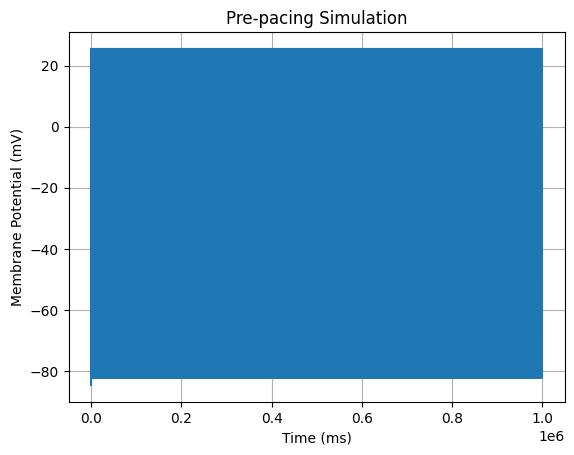

In [3]:
from tqdm import tqdm


@njit
def prepacing(dt, t_max, stim_mask, curr_value, u,
              nai, ki, cai, caup, carel, m, h, j_, d, f, oa, oi, ua, ui, xs,
              xr, fca, irel, vrel, urel, wrel,
              gna, gnab, gk1, gkr, gks, gto, gcal, gcab, gkur_coeff, F, T,
              R, Vc, Vj, Vup, Vrel, ibk, cao, nao, ko, caupmax, kup, kmnai,
              kmko, kmnancx, kmcancx, ksatncx, kmcmdn, kmtrpn, kmcsqn,
              trpnmax, cmdnmax, csqnmax, inacamax, inakmax, ipcamax, krel,
              iupmax, kq10):
        
    u_list = np.zeros((int(t_max/dt),), dtype=np.float64)
    u_list[0] = u
    
    for i in range(1, int(t_max/dt)):

        if stim_mask[i]:
            u += dt * curr_value

        ena, ek, eca = calc_equilibrum_potentials(nai, nao, ki, ko, cai,
                                                    cao, R, T, F,
                                                    where=calc_where)

        m = calc_gating_m(m, u, dt, where=calc_where)
        h = calc_gating_h(h, u, dt, where=calc_where)
        j_ = calc_gating_j(j_, u, dt, where=calc_where)

        ina = calc_ina(u, m, h, j_, gna, ena)
        ik1 = calc_ik1(u, gk1, ek)
        ito, oa, oi = calc_ito(u, dt, kq10, oa, oi, gto, ek)
        ikur, ua, ui = calc_ikur(u, dt, kq10, ua, ui, ek, gkur_coeff)
        ikr, xr = calc_ikr(u, dt, xr, gkr, ek)
        iks, xs = calc_iks(u, dt, xs, gks, ek)
        ical, d, f, fca = calc_ical(u, dt, d, f, cai, gcal, fca)
        inak = calc_inak(inakmax, nai, nao, ko, kmnai, kmko, F, u, R, T)
        inaca = calc_inaca(inacamax, nai, nao, cai, cao, kmnancx, kmcancx,
                            ksatncx, F, u, R, T)
        ibca = calc_ibca(gcab, eca, u)
        ibna = calc_ibna(gnab, ena, u)
        ipca = calc_ipca(ipcamax, cai)
        irel, urel, vrel, wrel = calc_irel(dt, urel, vrel, irel, wrel,
                                            ical, inaca, krel, carel, cai, u,
                                            F, Vrel)
        itr = calc_itr(caup, carel)
        iup = calc_iup(iupmax, cai, kup)
        iupleak = calc_iupleak(caup, caupmax, iupmax)

        caup += dt * calc_dcaup(iup, iupleak, itr, Vrel, Vup)
        nai += dt * calc_dnai(inak, inaca, ibna, ina, F, Vj)

        ki += dt * calc_dki(inak, ik1, ito, ikur, ikr, iks, ibk, F, Vj)
        cai += dt * calc_dcai(cai, inaca, ipca, ical, ibca, iup, iupleak,
                                irel, Vrel, Vup, trpnmax, kmtrpn, cmdnmax,
                                kmcmdn, F, Vj)

        carel += dt * calc_dcarel(carel, itr, irel, csqnmax, kmcsqn)

        rhs = (- calc_rhs(ina, ik1, ito, ikur, ikr, iks, ical, ipca, inak,
                            inaca, ibna, ibca))
        
        u = u + dt * rhs
        u_list[i] = u

    state_vars = [nai, ki, cai, caup, carel, m, h, j_, d, f, oa, oi, ua,
                    ui, xs, xr, fca, irel, vrel, urel, wrel]
    return u_list, state_vars


dt = 0.01
stim_duration = 0.5
stim_value = 100.
stim_interval = 1000
n_stim = 1000

t_max = (n_stim - 1) * stim_interval + 300

stim_mask = np.zeros(int(t_max/dt), dtype=bool)

for s in np.arange(n_stim):
    stim_start = s * stim_interval
    stim_end = stim_start + stim_duration
    
    start_idx = int(stim_start/dt)
    end_idx = int(min(stim_end, t_max)/dt)
    stim_mask[start_idx:end_idx] = True

# for i in range(10)

u_list, state_vars = prepacing(dt, t_max, stim_mask, 100., u,
          nai, ki, cai, caup, carel, m, h, j_, d, f, oa, oi, ua, ui, xs,
          xr, fca, irel, vrel, urel, wrel,
          gna, gnab, gk1, gkr, gks, gto, gcal, gcab, gkur_coeff, F, T,
          R, Vc, Vj, Vup, Vrel, ibk, cao, nao, ko,
          caupmax,kup, kmnai, kmko, kmnancx, kmcancx, ksatncx,
          kmcmdn,
          kmtrpn,
          kmcsqn,
          trpnmax,
          cmdnmax,
          csqnmax,
          inacamax,
          inakmax,
          ipcamax,
          krel,
          iupmax,kq10)

import matplotlib.pyplot as plt

plt.plot(np.arange(len(u_list)) * dt, u_list)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Pre-pacing Simulation')
plt.grid()
plt.show()

In [5]:
%timeit u_list, state_vars = prepacing(dt, dt, stim_mask, 100., u, nai, ki, cai, caup, carel, m, h, j_, d, f, oa, oi, ua, ui, xs, xr, fca, irel, vrel, urel, wrel, gna, gnab, gk1, gkr, gks, gto, gcal, gcab, gkur_coeff, F, T, R, Vc, Vj, Vup, Vrel, ibk, cao, nao, ko, caupmax,kup, kmnai, kmko, kmnancx, kmcancx, ksatncx, kmcmdn, kmtrpn, kmcsqn, trpnmax, cmdnmax, csqnmax, inacamax, inakmax, ipcamax, krel, iupmax, kq10)

1.28 μs ± 9.93 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


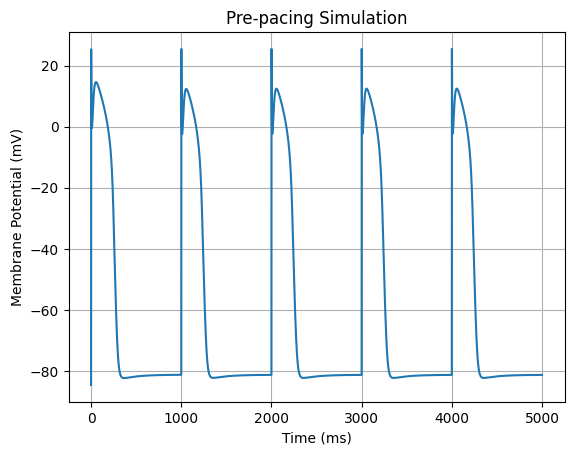

In [15]:
plt.plot(np.arange(len(u_list))[:500000] * dt, u_list[:500000])
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.title('Pre-pacing Simulation')
plt.grid()
plt.show()